In [13]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from typing import Dict, List, Tuple, Optional, Union
from dataclasses import dataclass
import bisect
from collections import defaultdict, Counter
import random

# PyTorch and PyTorch Geometric
import torch
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader
from torch_geometric.nn import GCNConv, BatchNorm, GATConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Utilities
import pickle
from tqdm import tqdm
import logging
import time
from pathlib import Path

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Visualization
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

warnings.filterwarnings('ignore')

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("training_wrr_gnn.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()

# Model directory
MODEL_DIR = "/root/projects/my-herosim/src/notebooks/models"
os.makedirs(MODEL_DIR, exist_ok=True)

## Configuration and Constants


In [14]:
@dataclass
class ModelConfig:
    """Configuration for the WRR-based GNN model"""
    # Model architecture
    hidden_dim: int = 128
    num_layers: int = 4
    dropout: float = 0.2
    attention_heads: int = 4
    
    # Training
    learning_rate: float = 0.001
    batch_size: int = 32  # Smaller batch since we have fewer nodes per graph
    num_epochs: int = 50
    patience: int = 15
    min_delta: float = 1e-4
    
    # WRR-specific configuration
    use_composite_score: bool = True  # Predict composite scores instead of raw latency
    score_normalization: str = 'sigmoid'  # 'sigmoid', 'softmax', or 'none'
    
    # Composite score weights - these define the WRR optimization strategy
    weight_latency: float = 0.4        # Fast execution
    weight_queue: float = 0.25         # Low queueing delay
    weight_cold_start: float = 0.15    # Avoid cold starts
    weight_energy: float = 0.1         # Energy efficiency
    weight_utilization: float = 0.1    # Load balancing
    
    # Data processing
    normalize_features: bool = True
    num_physical_nodes: int = 10  # Fixed number of physical nodes
    
config = ModelConfig()

# Infrastructure constants based on actual setup
PLATFORM_TYPES = ['rpiCpu', 'xavierCpu', 'xavierGpu', 'xavierDla', 'pynqFpga']
TASK_TYPES = ['dnn1', 'dnn2']
HARDWARE_TYPES = ['cpu', 'gpu', 'dla', 'fpga']
PHYSICAL_NODES = [f'node{i}' for i in range(10)]  # node0 to node9

# Load static infrastructure data
INFRASTRUCTURE_PATH = "/root/projects/my-herosim/src/notebooks/data/infrastructure/infrastructure.json"
PLATFORM_TYPES_PATH = "/root/projects/my-herosim/src/notebooks/data/infrastructure/platform-types.json"
TASK_TYPES_PATH = "/root/projects/my-herosim/src/notebooks/data/infrastructure/task-types.json"

with open(INFRASTRUCTURE_PATH, 'r') as f:
    INFRASTRUCTURE_DATA = json.load(f)
with open(PLATFORM_TYPES_PATH, 'r') as f:
    PLATFORM_TYPES_DATA = json.load(f)
with open(TASK_TYPES_PATH, 'r') as f:
    TASK_TYPES_DATA = json.load(f)

## Enhanced Data Loading and Processing


In [15]:
def load_results(results_folder):
    """Load simulation results from JSON files"""
    result_files = [f for f in os.listdir(results_folder) if f.endswith('.json')]
    results = {}
    
    for file in result_files:
        file_path = os.path.join(results_folder, file)
        with open(file_path, 'r') as f:
            results[file] = json.load(f)
    
    return results

def create_network_latency_lookup(latency_df: pd.DataFrame) -> Dict[Tuple[str, str], float]:
    """Create efficient lookup for network latency between node pairs"""
    lookup = {}
    
    for _, row in latency_df.iterrows():
        key = (row['source_node'], row['execution_node'])
        # Use the network latency value, defaulting to 0.1 for local communications
        latency = 0.1 if row['local_communications'] else row['network_latency']
        lookup[key] = latency
    
    return lookup


In [16]:
def extract_network_latency_matrix(results_data, experiment_name):
    """Extract network latency information from task results"""
    latency_data = []
    
    for result_file, result in results_data.items():
        if 'taskResults' in result['stats']:
            for task in result['stats']['taskResults']:
                latency_info = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'source_node': task['sourceNode'],
                    'execution_node': task['executionNode'],
                    'network_latency': task['networkLatency'],
                    'local_communications': task['localCommunications']
                }
                latency_data.append(latency_info)
    
    return pd.DataFrame(latency_data)


In [17]:
def extract_node_infrastructure_features(node_name: str) -> Dict:
    """Extract static infrastructure features for a physical node"""
    # Find node in infrastructure data
    node_data = None
    for node_info in INFRASTRUCTURE_DATA['nodes']:
        if node_info['node_name'] == node_name:
            node_data = node_info
            break
    
    if not node_data:
        raise ValueError(f"Node {node_name} not found in infrastructure")
    
    # Basic node specifications
    features = {
        'node_name': node_name,
        'memory': node_data['memory'],
        'total_platforms': len(node_data['platforms'])
    }
    
    # Platform composition - count each platform type
    platform_counts = Counter(node_data['platforms'])
    for platform_type in PLATFORM_TYPES:
        features[f'count_{platform_type}'] = platform_counts.get(platform_type, 0)
        features[f'has_{platform_type}'] = 1 if platform_counts.get(platform_type, 0) > 0 else 0
    
    # Hardware type composition
    hardware_counts = defaultdict(int)
    for platform_type in node_data['platforms']:
        if platform_type in PLATFORM_TYPES_DATA:
            hardware = PLATFORM_TYPES_DATA[platform_type]['hardware']
            hardware_counts[hardware] += 1
    
    for hardware_type in HARDWARE_TYPES:
        features[f'count_{hardware_type}'] = hardware_counts.get(hardware_type, 0)
    
    # Compute aggregate platform capabilities
    total_price = sum(PLATFORM_TYPES_DATA[pt]['price'] * platform_counts[pt] 
                     for pt in platform_counts if pt in PLATFORM_TYPES_DATA)
    total_idle_energy = sum(PLATFORM_TYPES_DATA[pt]['idleEnergy'] * platform_counts[pt] 
                           for pt in platform_counts if pt in PLATFORM_TYPES_DATA)
    
    features.update({
        'total_platform_price': total_price,
        'total_idle_energy': total_idle_energy,
        'avg_platform_price': total_price / max(features['total_platforms'], 1),
        'avg_idle_energy': total_idle_energy / max(features['total_platforms'], 1)
    })
    
    return features

def extract_node_performance_metrics(results, experiment_name):
    """Extract performance metrics aggregated by physical node"""
    node_data = []
    platform_data = []

    for result_file, result in results.items():
        if 'nodeResults' in result['stats']:
            for node in result['stats']['nodeResults']:
                # Convert numeric node_id to string format
                node_id = f"node{node['nodeId']}"
                
                # Get static infrastructure features
                try:
                    infra_features = extract_node_infrastructure_features(node_id)
                except ValueError:
                    continue  # Skip unknown nodes
                
                # Basic node metrics
                node_metrics = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'node_id': node_id,
                    'unused': node['unused'],
                    'scheduling_time': node['schedulingTime'],
                    'storage_time': node['storageTime'],
                    'local_dependencies': node['localDependencies'],
                    'cache_hits': node['cacheHits'],
                }
                
                # Add infrastructure features
                node_metrics.update(infra_features)

                # Energy metrics by platform type
                total_energy = 0
                total_idle_energy = 0
                total_idle_time = 0
                
                if 'energy' in node:
                    for platform_type, energy in node['energy'].items():
                        node_metrics[f'energy_{platform_type}'] = energy
                        total_energy += energy

                if 'energyIdle' in node:
                    for platform_type, energy in node['energyIdle'].items():
                        node_metrics[f'idle_energy_{platform_type}'] = energy
                        total_idle_energy += energy

                if 'idleTime' in node:
                    for platform_type, time_val in node['idleTime'].items():
                        node_metrics[f'idle_time_{platform_type}'] = time_val
                        total_idle_time += time_val

                # Aggregate metrics
                node_metrics.update({
                    'total_energy': total_energy,
                    'total_idle_energy': total_idle_energy,
                    'total_idle_time': total_idle_time,
                    'energy_efficiency': total_energy / max(total_idle_time, 1),
                    'cache_hit_rate': node_metrics['cache_hits'] / max(node_metrics['local_dependencies'], 1)
                })

                node_data.append(node_metrics)

                # Platform-level metrics for compatibility
                if 'platformResults' in node:
                    for platform in node['platformResults']:
                        platform_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node_id,
                            'platform_id': platform['platformId'],
                            'platform_type': platform['platformType']['shortName'],
                            'platform_hardware': platform['platformType']['hardware'],
                            'platform_price': platform['platformType']['price'],
                            'energy': platform['energy'],
                            'energy_idle': platform['energyIdle'],
                            'idle_time': platform['idleTime'],
                            'idle_proportion': platform['idleProportion'],
                            'storage_time': platform['storageTime']
                        }
                        
                        # Calculate derived metrics
                        active_time = platform_metrics['idle_time'] / max(platform_metrics['idle_proportion'], 0.001)
                        platform_metrics.update({
                            'active_time': active_time,
                            'utilization': 1 - platform_metrics['idle_proportion'],
                            'energy_per_active_time': platform_metrics['energy'] / max(active_time, 1),
                            'performance_per_dollar': active_time / max(platform_metrics['platform_price'], 1)
                        })
                        
                        platform_data.append(platform_metrics)

    return pd.DataFrame(node_data), pd.DataFrame(platform_data)


In [18]:
def calculate_wrr_composite_score(task_data: Dict, config=None) -> float:
    """Calculate composite performance score for WRR scheduling"""
    
    if config is None:
        # Default weights if no config provided
        weight_latency = 0.4
        weight_queue = 0.25
        weight_cold_start = 0.15
        weight_energy = 0.1
        weight_utilization = 0.1
    else:
        weight_latency = config.weight_latency
        weight_queue = config.weight_queue
        weight_cold_start = config.weight_cold_start
        weight_energy = config.weight_energy
        weight_utilization = config.weight_utilization
    
    # Normalize individual components to [0,1] range (higher = better)
    
    # 1. Latency component (lower latency = higher score)
    latency_ms = task_data['end_to_end_latency']
    latency_score = 1.0 / (1.0 + latency_ms / 100.0)  # Normalize around 100ms
    
    # 2. Queue time component (lower queue time = higher score)
    queue_ms = task_data['queue_time']
    queue_score = 1.0 / (1.0 + queue_ms / 50.0)  # Normalize around 50ms
    
    # 3. Cold start component (no cold start = higher score)
    cold_start_score = 0.3 if task_data['cold_started'] else 1.0
    
    # 4. Energy efficiency component (lower energy per ms = higher score)
    energy_per_ms = task_data['energy'] / max(task_data['execution_time'], 1)
    energy_score = 1.0 / (1.0 + energy_per_ms)  # Normalize energy efficiency
    
    # 5. Load balancing component (avoid overloaded nodes)
    # Use wait_time as proxy for node load
    wait_ms = task_data['wait_time']
    utilization_score = 1.0 / (1.0 + wait_ms / 20.0)  # Normalize around 20ms
    
    # Weighted combination using config weights
    composite_score = (
        weight_latency * latency_score +
        weight_queue * queue_score +
        weight_cold_start * cold_start_score +
        weight_energy * energy_score +
        weight_utilization * utilization_score
    )
    
    return composite_score

def extract_enhanced_task_metrics(results, experiment_name):
    """Extract enhanced task metrics with additional features"""
    tasks_data = []

    for result_file, result in results.items():
        if 'taskResults' in result['stats']:
            for task in result['stats']['taskResults']:
                task_data = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'task_id': task['taskId'],
                    'dispatched_time': task['dispatchedTime'],
                    'scheduled_time': task['scheduledTime'],
                    'arrived_time': task['arrivedTime'],
                    'started_time': task['startedTime'],
                    'done_time': task['doneTime'],
                    'task_type': task['taskType']['name'],
                    'platform_type': task['platform']['shortName'],
                    'platform_hardware': task['platform']['hardware'],
                    'elapsed_time': task['elapsedTime'],
                    'pull_time': task['pullTime'],
                    'cold_start_time': task['coldStartTime'],
                    'execution_time': task['executionTime'],
                    'wait_time': task['waitTime'],
                    'queue_time': task['queueTime'],
                    'initialization_time': task['initializationTime'],
                    'compute_time': task['computeTime'],
                    'communications_time': task['communicationsTime'],
                    'cold_started': task['coldStarted'],
                    'cache_hit': task['cacheHit'],  
                    'local_dependencies': task['localDependencies'],
                    'local_communications': task['localCommunications'],
                    'energy': task['energy'],
                    'network_latency': task['networkLatency'],
                    'source_node': task['sourceNode'],
                    'execution_node': task['executionNode'],
                    'execution_platform': task['executionPlatform'],
                }

                # Calculate task latency components
                task_data['scheduling_latency'] = task_data['scheduled_time'] - task_data['dispatched_time']
                task_data['arrival_latency'] = task_data['arrived_time'] - task_data['scheduled_time']
                task_data['start_latency'] = task_data['started_time'] - task_data['arrived_time']
                task_data['processing_latency'] = task_data['done_time'] - task_data['started_time']
                task_data['end_to_end_latency'] = task_data['done_time'] - task_data['dispatched_time']
                
                # Additional derived features
                task_data.update({
                    'task_complexity': task_data['compute_time'] + task_data['communications_time'],
                    'overhead_ratio': (task_data['end_to_end_latency'] - task_data['execution_time']) / max(task_data['execution_time'], 1),
                    'communication_ratio': task_data['communications_time'] / max(task_data['compute_time'], 1),
                    'cold_start_penalty': task_data['cold_start_time'] / max(task_data['execution_time'], 1)
                })
                
                # WRR Composite Score Calculation
                task_data['wrr_composite_score'] = calculate_wrr_composite_score(task_data)

                tasks_data.append(task_data)

    return pd.DataFrame(tasks_data)


In [19]:
def load_experiment_data(experiments, cache_dir="src/notebooks/wrr_cache"):
    """Load experiment data with node-based features"""
    os.makedirs(cache_dir, exist_ok=True)
    experiment_data = {}

    for name, folder in experiments.items():
        cache_path = os.path.join(cache_dir, f"{name}_wrr_data.pkl")
        if os.path.exists(cache_path):
            logger.info(f"Loading cached data for {name}")
            with open(cache_path, "rb") as f:
                experiment_data[name] = pickle.load(f)
        else:
            logger.info(f"Processing data for {name}")
            results = load_results(folder)
            node_df, platform_df = extract_node_performance_metrics(results, name)
            task_df = extract_enhanced_task_metrics(results, name)
            latency_df = extract_network_latency_matrix(results, name)
            
            experiment_data[name] = {
                "node_df": node_df,
                "platform_df": platform_df,
                "task_df": task_df,
                "latency_df": latency_df
            }
            
            logger.info(f"Caching data for {name}")
            with open(cache_path, "wb") as f:
                pickle.dump(experiment_data[name], f)
                
    return experiment_data

## Feature Engineering


In [20]:
# Replace the broken feature engineering with simulation-based features
class SimulationBasedFeatureEngineer:
    """Feature engineering using ONLY features that actually influence simulation latency"""
    
    def __init__(self):
        self.feature_scaler = None
        self.fitted = False
        self.node_df = None
        
        # Storage performance data (from simulation storage-types.json)
        self.storage_types = {
            'eMMC': {'throughput': {'read': 294, 'write': 82}, 'latency': {'read': 0.00452, 'write': 0.00452}},
            'flashCard': {'throughput': {'read': 100, 'write': 40}, 'latency': {'read': 0.00122, 'write': 0.00122}},
            'someRemote': {'throughput': {'read': 108, 'write': 108}, 'latency': {'read': 0.015, 'write': 0.015}}
        }
        
    def fit(self, task_df, node_df):
        """Fit scaler on numerical features using multiple task samples"""
        logger.info("Fitting simulation-based feature scalers")
        
        # Store node_df for later use
        self.node_df = node_df
        
        # Collect feature samples to understand the data distribution
        feature_samples = []
        sample_tasks = task_df.sample(n=min(1000, len(task_df)))
        
        for _, task in sample_tasks.iterrows():
            for node_name in PHYSICAL_NODES:
                try:
                    features = self._extract_raw_features(node_name, task['task_type'])
                    feature_samples.append(features[:19])  # Only numerical features
                except:
                    continue
        
        if feature_samples:
            self.feature_scaler = RobustScaler()
            self.feature_scaler.fit(feature_samples)
            logger.info(f"Fitted scaler on {len(feature_samples)} feature samples")
        
        self.fitted = True
        
    def _extract_raw_features(self, node_name: str, task_type: str) -> List[float]:
        return self.extract_node_features(node_name, task_type, apply_scaling=False)
    
    def extract_node_features(self, node_name: str, task_type: str, apply_scaling: bool = True) -> List[float]:
        
        # Get node data
        if self.node_df is None:
            raise ValueError("Feature engineer not fitted. Call fit() first.")
        node_data = self.node_df[self.node_df['node_name'] == node_name].iloc[0]
        
        # Get task type data 
        task_type_data = TASK_TYPES_DATA[task_type]
        
        # 1. NODE MEMORY CHARACTERISTICS (2 features) - affects platform availability
        node_memory = float(node_data['memory'])
        node_memory_tier = 0 if node_memory <= 1 else (1 if node_memory <= 8 else 2)
        
        # 2. PLATFORM COUNTS (5 features) - affects platform availability
        rpi_cpu_count = int(node_data['count_rpiCpu'])
        xavier_cpu_count = int(node_data['count_xavierCpu'])
        xavier_gpu_count = int(node_data['count_xavierGpu'])
        xavier_dla_count = int(node_data['count_xavierDla'])
        pynq_fpga_count = int(node_data['count_pynqFpga'])
        
        # 3. TASK EXECUTION PERFORMANCE (6 features) - CORE LATENCY DRIVERS
        platform_counts_dict = {
            'rpiCpu': rpi_cpu_count,
            'xavierCpu': xavier_cpu_count,
            'xavierGpu': xavier_gpu_count,
            'xavierDla': xavier_dla_count,
            'pynqFpga': pynq_fpga_count
        }
        available_platforms = [p for p in task_type_data['platforms'] if platform_counts_dict.get(p, 0) > 0]
        if available_platforms:
            # Execution time statistics across available platforms
            execution_times = [task_type_data['executionTime'][p] for p in available_platforms]
            min_execution_time = min(execution_times)      # Best case (fastest platform)
            max_execution_time = max(execution_times)      # Worst case (slowest platform)
            avg_execution_time = sum(execution_times) / len(execution_times)  # Average case
            
            # Cold start statistics across available platforms
            cold_starts = [task_type_data['coldStartDuration'][p] for p in available_platforms]
            min_cold_start = min(cold_starts)              # Best case cold start
            max_cold_start = max(cold_starts)              # Worst case cold start
            avg_cold_start = sum(cold_starts) / len(cold_starts)  # Average cold start
        else:
            # No compatible platforms - use penalty values
            min_execution_time = max_execution_time = avg_execution_time = 10.0
            min_cold_start = max_cold_start = avg_cold_start = 10.0
        
        # 4. TASK I/O CHARACTERISTICS (4 features) - affects I/O latency
        # Get task I/O sizes based on application type
        app_type = 'nofs-' + task_type  # nofs-dnn1 or nofs-dnn2
        state_size_data = task_type_data['stateSize'].get(app_type, {})
        task_input_size = state_size_data.get('input', 153600) / 1000  # Convert to KB
        task_output_size = state_size_data.get('output', 8000) / 1000   # Convert to KB
        
        # Get storage performance for this node
        storage_types = node_data.get('storage_types', ['flashCard', 'someRemote'])
        local_storage = [s for s in storage_types if s != 'someRemote']
        if local_storage:
            # Use best local storage performance
            storage_read_speed = max(self.storage_types[s]['throughput']['read'] for s in local_storage)
            storage_write_speed = max(self.storage_types[s]['throughput']['write'] for s in local_storage)
        else:
            # Only remote storage available
            storage_read_speed = self.storage_types['someRemote']['throughput']['read']
            storage_write_speed = self.storage_types['someRemote']['throughput']['write']

        # 5. TASK-PLATFORM MEMORY COMPATIBILITY (2 features) - affects platform availability
        if available_platforms:
            memory_reqs = [task_type_data['memoryRequirements'][p] for p in available_platforms]
            min_memory_required = min(memory_reqs)  # Least memory needed
            max_memory_required = max(memory_reqs)  # Most memory needed
        else:
            min_memory_required = max_memory_required = 1.0  # Penalty for no compatible platforms

        # 6. CATEGORICAL ENCODINGS (5 features)
        # Task type encoding (2 features)
        task_type_encoding = [1 if task_type == 'dnn1' else 0, 1 if task_type == 'dnn2' else 0]

        # Node type encoding based on dominant platform (3 features)
        node_type_name = node_data.get('node_type', 'unknown')
        node_type_encoding = [
            1 if 'rpi' in node_type_name.lower() else 0,
            1 if 'xavier' in node_type_name.lower() else 0, 
            1 if 'pynq' in node_type_name.lower() else 0
        ]

        # COMBINE ALL FEATURES (24 total)
        # Memory(2) + Platforms(5) + Execution(6) + I/O(4) + Memory_compat(2) + Categorical(5) = 24
        node_features = [
            # Memory characteristics (2) 
            node_memory, node_memory_tier,
            # Platform counts (5)
            rpi_cpu_count, xavier_cpu_count, xavier_gpu_count, xavier_dla_count, pynq_fpga_count,
            # Execution performance (6) - MOST IMPORTANT FOR LATENCY
            min_execution_time, max_execution_time, avg_execution_time,
            min_cold_start, max_cold_start, avg_cold_start,
            # I/O characteristics (4) - affects communication latency
            task_input_size, task_output_size, storage_read_speed, storage_write_speed,
            # Memory compatibility (2) - affects platform availability
            min_memory_required, max_memory_required,
            # Categorical encodings (5)
            *task_type_encoding, *node_type_encoding
        ]
        
        # Apply scaling to numerical features if requested and fitted
        if apply_scaling and self.fitted and self.feature_scaler is not None:
            # Split into numerical (first 19) and categorical (last 5) features
            numerical_features = node_features[:19]
            categorical_features = node_features[19:]
            
            # Scale numerical features
            numerical_scaled = self.feature_scaler.transform([numerical_features])[0]
            
            # Combine scaled numerical + unchanged categorical
            node_features = list(numerical_scaled) + categorical_features
        
        return node_features

## GNN Model and Dataset


In [21]:
class NodeBasedDataset(IterableDataset):
    """Dataset for node-based graphs"""
    
    def __init__(self, task_df, node_df, feature_engineer, num_samples=10000, target_task_types=None):
        self.task_df = task_df
        self.node_df = node_df
        self.feature_engineer = feature_engineer
        self.num_samples = num_samples
        self.target_task_types = target_task_types or TASK_TYPES
        
        # Create task lookup by node and task type for faster access
        self.task_lookup = defaultdict(lambda: defaultdict(list))
        for _, task in task_df.iterrows():
            self.task_lookup[task['execution_node']][task['task_type']].append(task.to_dict())
        
        logger.info(f"WRR Dataset initialized with {len(task_df)} tasks across {len(node_df)} nodes")
        logger.info(f"Composite score range: {task_df['wrr_composite_score'].min():.3f} - {task_df['wrr_composite_score'].max():.3f}")

    def __len__(self):
        return self.num_samples
        
    def create_graph(self, target_task_type: str, target_task_data: Dict) -> Optional[Data]:
        """Create a single graph with 10 nodes representing physical infrastructure"""
        try:
            # Create node features for all 10 physical nodes
            node_features = []
            target_nodes = []  # Which nodes have actual WRR score targets
            score_targets = []
            
            for node_name in PHYSICAL_NODES:
                # Extract features for this node given the task type (inference-compatible)
                features = self.feature_engineer.extract_node_features(
                    node_name, target_task_type
                )
                node_features.append(features)
                
                # Check if this node executed tasks of this type
                if (node_name in self.task_lookup and 
                    target_task_type in self.task_lookup[node_name]):
                    
                    # Use the target task data if it matches this node
                    if target_task_data.get('execution_node') == node_name:
                        target_nodes.append(len(node_features) - 1)  # Current node index
                        score_targets.append(target_task_data['wrr_composite_score'])
            
            if not target_nodes:
                return None  # No valid targets for this graph
            
            # Create network topology edges (all nodes connected)
            edge_index = []
            edge_attr = []
            
            for i in range(len(PHYSICAL_NODES)):
                for j in range(len(PHYSICAL_NODES)):
                    if i != j:
                        node_i_name = PHYSICAL_NODES[i]
                        node_j_name = PHYSICAL_NODES[j]
                        
                        # Get network latency from infrastructure
                        network_latency = 0.1  # Default local latency
                        for node_data in INFRASTRUCTURE_DATA['nodes']:
                            if node_data['node_name'] == node_i_name:
                                network_map = node_data.get('network_map', {})
                                # Convert to seconds and normalize
                                network_latency = network_map.get(node_j_name, 100.0) / 1000.0
                                break
                        
                        edge_index.append([i, j])
                        edge_attr.append([
                            network_latency,
                            1.0 if node_i_name == node_j_name else 0.0  # Locality indicator
                        ])
            
            # Convert to tensors
            x = torch.tensor(node_features, dtype=torch.float)
            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(edge_attr, dtype=torch.float)
            
            # Create target mask and targets
            mask = torch.zeros(len(PHYSICAL_NODES), dtype=torch.bool)
            targets = torch.zeros(len(PHYSICAL_NODES), dtype=torch.float)
            
            for idx, target_score in zip(target_nodes, score_targets):
                mask[idx] = True
                targets[idx] = target_score
            
            # Apply score normalization if configured
            if config.score_normalization == 'sigmoid':
                targets[mask] = torch.sigmoid(targets[mask])
            elif config.score_normalization == 'softmax' and mask.sum() > 1:
                valid_targets = targets[mask]
                targets[mask] = torch.softmax(valid_targets, dim=0)
            
            return Data(
                x=x,
                edge_index=edge_index,
                edge_attr=edge_attr,
                mask=mask,
                wrr_score_target=targets,
                task_type=target_task_type,
                num_nodes=len(PHYSICAL_NODES)
            )
            
        except Exception as e:
            logger.warning(f"Failed to create graph: {e}")
            return None
    
    def __iter__(self):
        """Generate graphs on demand"""
        successful_graphs = 0
        failures = 0
        
        # Sample tasks for graph creation
        sampled_tasks = self.task_df.sample(n=min(self.num_samples * 3, len(self.task_df)))
        
        for _, task in sampled_tasks.iterrows():
            if successful_graphs >= self.num_samples:
                break
                
            task_data = task.to_dict()
            task_type = task_data['task_type']
            
            if task_type not in self.target_task_types:
                continue
                
            graph = self.create_graph(task_type, task_data)
            if graph is not None:
                yield graph
                successful_graphs += 1
            else:
                failures += 1
        
        logger.info(f"Dataset iteration complete: {successful_graphs} successful graphs, {failures} failures")

In [25]:
class WRRNodeBasedGNN(torch.nn.Module):
    """Node-based GNN that predicts WRR composite scores for physical nodes"""
    
    def __init__(self, node_feature_dim: int, edge_feature_dim: int, config: ModelConfig):
        super(WRRNodeBasedGNN, self).__init__()

        self.config = config
        self.node_feature_dim = node_feature_dim
        self.edge_feature_dim = edge_feature_dim
        
        # Input encoders
        self.node_encoder = torch.nn.Sequential(
            torch.nn.Linear(node_feature_dim, config.hidden_dim),
            torch.nn.BatchNorm1d(config.hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(config.dropout)
        )
        
        self.edge_encoder = torch.nn.Sequential(
            torch.nn.Linear(edge_feature_dim, config.hidden_dim),
            torch.nn.BatchNorm1d(config.hidden_dim),
            torch.nn.ReLU()
        )
        
        # Graph convolution layers
        self.conv_layers = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()
        
        for i in range(config.num_layers):
            self.conv_layers.append(
                GATConv(
                    config.hidden_dim, 
                    config.hidden_dim // config.attention_heads,
                    heads=config.attention_heads, 
                    dropout=config.dropout,
                    edge_dim=config.hidden_dim
                )
            )
            self.batch_norms.append(BatchNorm(config.hidden_dim))
        
        # Output layers - predict WRR composite scores
        self.wrr_score_predictor = torch.nn.Sequential(
            torch.nn.Linear(config.hidden_dim, config.hidden_dim // 2),
            torch.nn.ReLU(),
            torch.nn.Dropout(config.dropout),
            torch.nn.Linear(config.hidden_dim // 2, 1),
            torch.nn.Sigmoid() if config.score_normalization == 'sigmoid' else torch.nn.Identity()
        )
        
    def forward(self, x, edge_index, edge_attr):
        # Encode inputs
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)
        
        # Apply graph convolutions with residual connections
        for i, (conv, norm) in enumerate(zip(self.conv_layers, self.batch_norms)):
            x_new = conv(x, edge_index, edge_attr)
            x_new = norm(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.config.dropout, training=self.training)
            
            # Residual connection
            if x.size(-1) == x_new.size(-1):
                x = x + x_new
            else:
                x = x_new
        
        # Predict WRR composite scores
        wrr_score_pred = self.wrr_score_predictor(x)
        
        return {
            'wrr_score': wrr_score_pred.squeeze(-1)
        }

## Data Loading and Preprocessing


In [26]:
# Load experiment data
experiments = {
    "knative": "/root/projects/my-herosim/src/notebooks/data/results_sim/125-225-5clients-knative-with-network",
}

logger.info("Loading experiment data for WRR approach...")
experiment_data = load_experiment_data(experiments, cache_dir="src/notebooks/wrr_cache")

# Extract data for analysis
results = experiment_data['knative']
node_df = results['node_df']
platform_df = results['platform_df'] 
task_df = results['task_df']

print(f"Data loaded successfully:")
print(f"- Tasks: {len(task_df)}")
print(f"- Node records: {len(node_df)}")
print(f"- Platform records: {len(platform_df)}")

# Initialize inference-compatible feature engineer
feature_engineer = SimulationBasedFeatureEngineer()
feature_engineer.fit(task_df, node_df)

[2025-07-16 11:23:00,767] INFO - Loading experiment data for WRR approach...
[2025-07-16 11:23:00,772] INFO - Loading cached data for knative
[2025-07-16 11:23:01,207] INFO - Fitting simulation-based feature scalers


Data loaded successfully:
- Tasks: 411049
- Node records: 20
- Platform records: 128


[2025-07-16 11:23:03,803] INFO - Fitted scaler on 10000 feature samples


In [27]:
# Create node-based datasets
print("=== Creating Node-Based Datasets ===")

# Split data into train/validation
train_tasks, val_tasks = train_test_split(task_df, test_size=0.2, random_state=42)
print(f"Train tasks: {len(train_tasks)}, Validation tasks: {len(val_tasks)}")

# Create datasets
train_dataset = NodeBasedDataset(
    task_df=train_tasks, 
    node_df=node_df, 
    feature_engineer=feature_engineer,
    num_samples=5000
)

val_dataset = NodeBasedDataset(
    task_df=val_tasks, 
    node_df=node_df, 
    feature_engineer=feature_engineer,
    num_samples=1000
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    num_workers=0
)

# Calculate expected iterations for progress tracking
train_iterations = len(train_dataset) // config.batch_size
val_iterations = len(val_dataset) // config.batch_size
print(f"Expected iterations - Train: {train_iterations}, Validation: {val_iterations}")
print(f"Note: If tqdm shows wrong total (like 10277), ignore it - actual progress is ~{train_iterations} iterations")

print("=== Testing Dataset Creation ===")

# Test single graph creation
sample_task = train_tasks.iloc[0].to_dict()
test_graph = train_dataset.create_graph(sample_task['task_type'], sample_task)

if test_graph is not None:
    print(f"✅ Graph creation successful!")
    print(f"  Nodes: {test_graph.x.shape[0]} (expected: 10)")
    print(f"  Node features: {test_graph.x.shape[1]}")
    print(f"  Edges: {test_graph.edge_index.shape[1]}")
    print(f"  Edge features: {test_graph.edge_attr.shape[1]}")
    print(f"  Valid targets: {test_graph.mask.sum()}")
    print(f"  WRR Score range: {test_graph.wrr_score_target[test_graph.mask].min():.3f} - {test_graph.wrr_score_target[test_graph.mask].max():.3f}")
    print(f"  NOTE: Each graph has 1 target (execution node). Same task = same WRR score is expected.")
else:
    print("❌ Graph creation failed!")

# Test multiple different tasks to show variety
print("\n=== Testing WRR Score Variety Across Tasks ===")
different_scores = []
for i in range(min(10, len(train_tasks))):
    task = train_tasks.iloc[i].to_dict()
    graph = train_dataset.create_graph(task['task_type'], task)
    if graph is not None and graph.mask.sum() > 0:
        score = graph.wrr_score_target[graph.mask].item()
        different_scores.append(score)

if different_scores:
    print(f"✅ WRR Score variety confirmed!")
    print(f"  Sample scores: {[f'{score:.3f}' for score in different_scores[:5]]}")
    print(f"  Score range: {min(different_scores):.3f} - {max(different_scores):.3f}")
    print(f"  Unique values: {len(set(f'{score:.3f}' for score in different_scores))}/{len(different_scores)}")
else:
    print("❌ No score variety found!")

# Test batch loading
print("\\n=== Testing Batch Loading ===")
sample_batch = next(iter(train_loader))
node_feature_dim = sample_batch.x.size(1)
edge_feature_dim = sample_batch.edge_attr.size(1)

print(f"Feature dimensions:")
print(f"- Node features: {node_feature_dim}")
print(f"- Edge features: {edge_feature_dim}")

print(f"Batch details:")
print(f"- Batch size: {sample_batch.batch.max().item() + 1}")
print(f"- Total nodes: {sample_batch.x.shape[0]}")
print(f"- Total edges: {sample_batch.edge_index.shape[1]}")
print(f"- Valid targets: {sample_batch.mask.sum()}")

# Initialize WRR model
model = WRRNodeBasedGNN(
    node_feature_dim=node_feature_dim,
    edge_feature_dim=edge_feature_dim,
    config=config
)

logger.info(f"WRR-based model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

# Initialize trainer with early stopping
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

class WRRNodeBasedTrainer:
    def __init__(self, model, config):
        self.model = model
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        
        self.optimizer = torch.optim.AdamW(
            model.parameters(), 
            lr=config.learning_rate,
            weight_decay=1e-5
        )
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3
        )
        self.criterion = torch.nn.MSELoss()
        self.early_stopping = EarlyStopping(patience=config.patience, min_delta=config.min_delta)
        
    def train_epoch(self, data_loader):
        self.model.train()
        total_loss = 0
        num_batches = 0
        predictions = []
        targets = []
        
        for batch in tqdm(data_loader, desc="Training"):
            batch = batch.to(self.device)
            
            self.optimizer.zero_grad()
            
            # Forward pass (removed batch parameter)
            outputs = self.model(batch.x, batch.edge_index, batch.edge_attr)
            
            # Calculate loss only on nodes with targets
            if batch.mask.sum() > 0:
                loss = self.criterion(
                    outputs['wrr_score'][batch.mask], 
                    batch.wrr_score_target[batch.mask]
                )
                loss.backward()
                self.optimizer.step()
                
                total_loss += loss.item()
                num_batches += 1
                
                # Collect metrics
                predictions.extend(outputs['wrr_score'][batch.mask].detach().cpu().numpy())
                targets.extend(batch.wrr_score_target[batch.mask].cpu().numpy())
        
        # Calculate training metrics for WRR scores
        metrics = {}
        if predictions:
            predictions = np.array(predictions)
            targets = np.array(targets)
                
            metrics = {
                'train_r2': r2_score(targets, predictions),
                'train_mae': mean_absolute_error(targets, predictions),
                'train_score_range': f"{predictions.min():.3f}-{predictions.max():.3f}"
            }
        
        return total_loss / max(num_batches, 1), metrics
    
    def validate(self, data_loader):
        self.model.eval()
        total_loss = 0
        num_batches = 0
        predictions = []
        targets = []
        
        with torch.no_grad():
            for batch in tqdm(data_loader, desc="Validation"):
                batch = batch.to(self.device)
                
                # Forward pass (removed batch parameter)
                outputs = self.model(batch.x, batch.edge_index, batch.edge_attr)
                
                if batch.mask.sum() > 0:
                    loss = self.criterion(
                        outputs['wrr_score'][batch.mask], 
                        batch.wrr_score_target[batch.mask]
                    )
                    total_loss += loss.item()
                    num_batches += 1
                    
                    predictions.extend(outputs['wrr_score'][batch.mask].cpu().numpy())
                    targets.extend(batch.wrr_score_target[batch.mask].cpu().numpy())
        
        # Calculate validation metrics for WRR scores
        metrics = {}
        if predictions:
            predictions = np.array(predictions)
            targets = np.array(targets)
                
            metrics = {
                'val_r2': r2_score(targets, predictions),
                'val_mae': mean_absolute_error(targets, predictions),
                'val_score_range': f"{predictions.min():.3f}-{predictions.max():.3f}"
            }
        
        return total_loss / max(num_batches, 1), metrics
    
    def train(self, train_loader, val_loader):
        best_checkpoint_path = os.path.join(MODEL_DIR, 'best_wrr_gnn.pt')
        start_time = time.time()
        
        results = {
            'train_losses': [],
            'val_losses': [],
            'val_r2s': [],
            'val_maes': [],
            'train_metrics': [],
            'val_metrics': [],
            'training_time': 0.0
        }
        
        logger.info(f"Starting training on device: {self.device}")
        
        for epoch in range(self.config.num_epochs):
            # Training
            train_loss, train_metrics = self.train_epoch(train_loader)
            
            # Validation
            val_loss, val_metrics = self.validate(val_loader)
            
            # Learning rate scheduling
            self.scheduler.step(val_loss)
            
            # Store results
            results['train_losses'].append(train_loss)
            results['val_losses'].append(val_loss)
            results['val_r2s'].append(val_metrics.get('val_r2', 0.0))
            results['val_maes'].append(val_metrics.get('val_mae', float('inf')))
            results['train_metrics'].append(train_metrics)
            results['val_metrics'].append(val_metrics)
            
            logger.info(f"Epoch {epoch+1}/{self.config.num_epochs}")
            logger.info(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            logger.info(f"Val R²: {val_metrics.get('val_r2', 0.0):.4f}, Val MAE: {val_metrics.get('val_mae', float('inf')):.4f}")
            
            # Early stopping and checkpoint saving
            if self.early_stopping(val_loss, self.model):
                logger.info(f"Early stopping at epoch {epoch+1}")
                break
                
            # Save best model
            if val_loss == self.early_stopping.best_loss:
                torch.save({
                    'model_state_dict': self.model.state_dict(),
                    'config': self.config,
                    'epoch': epoch,
                    'val_loss': val_loss,
                    'val_r2': val_metrics.get('val_r2', 0.0)
                }, best_checkpoint_path)
                logger.info(f"Best model saved to {best_checkpoint_path}")
        
        results['training_time'] = time.time() - start_time
        return results

trainer = WRRNodeBasedTrainer(model, config)

# Start training
logger.info("Starting WRR-based GNN training...")
training_results = trainer.train(train_loader, val_loader)

=== Creating Node-Based Datasets ===
Train tasks: 328839, Validation tasks: 82210


[2025-07-16 11:23:22,015] INFO - WRR Dataset initialized with 328839 tasks across 20 nodes
[2025-07-16 11:23:22,019] INFO - Composite score range: 0.398 - 0.796
[2025-07-16 11:23:26,671] INFO - WRR Dataset initialized with 82210 tasks across 20 nodes
[2025-07-16 11:23:26,673] INFO - Composite score range: 0.398 - 0.796


Expected iterations - Train: 156, Validation: 31
Note: If tqdm shows wrong total (like 10277), ignore it - actual progress is ~156 iterations
=== Testing Dataset Creation ===
✅ Graph creation successful!
  Nodes: 10 (expected: 10)
  Node features: 24
  Edges: 90
  Edge features: 2
  Valid targets: 1
  WRR Score range: 0.634 - 0.634
  NOTE: Each graph has 1 target (execution node). Same task = same WRR score is expected.

=== Testing WRR Score Variety Across Tasks ===
✅ WRR Score variety confirmed!
  Sample scores: ['0.634', '0.608', '0.608', '0.665', '0.659']
  Score range: 0.608 - 0.676
  Unique values: 9/10
\n=== Testing Batch Loading ===


[2025-07-16 11:23:28,090] INFO - WRR-based model initialized with 146,561 parameters


Feature dimensions:
- Node features: 24
- Edge features: 2
Batch details:
- Batch size: 32
- Total nodes: 320
- Total edges: 2880
- Valid targets: 32


[2025-07-16 11:23:28,326] INFO - Starting WRR-based GNN training...
[2025-07-16 11:23:28,328] INFO - Starting training on device: cuda
Validation: 100%|██████████| 32/32 [00:04<00:00,  7.50it/s]
[2025-07-16 11:23:55,474] INFO - Epoch 1/50
[2025-07-16 11:23:55,474] INFO - Train Loss: 0.0020, Val Loss: 0.0010
[2025-07-16 11:23:55,475] INFO - Val R²: -0.9116, Val MAE: 0.0241
[2025-07-16 11:23:55,482] INFO - Best model saved to /root/projects/my-herosim/src/notebooks/models/best_wrr_gnn.pt
Validation: 100%|██████████| 32/32 [00:04<00:00,  7.40it/s]
[2025-07-16 11:24:22,269] INFO - Epoch 2/50
[2025-07-16 11:24:22,270] INFO - Train Loss: 0.0008, Val Loss: 0.0011
[2025-07-16 11:24:22,270] INFO - Val R²: -1.0962, Val MAE: 0.0255
Validation: 100%|██████████| 32/32 [00:04<00:00,  7.56it/s]
[2025-07-16 11:24:48,969] INFO - Epoch 3/50
[2025-07-16 11:24:48,969] INFO - Train Loss: 0.0007, Val Loss: 0.0007
[2025-07-16 11:24:48,969] INFO - Val R²: -0.3797, Val MAE: 0.0209
[2025-07-16 11:24:48,976] INF

## Results Analysis and Visualization


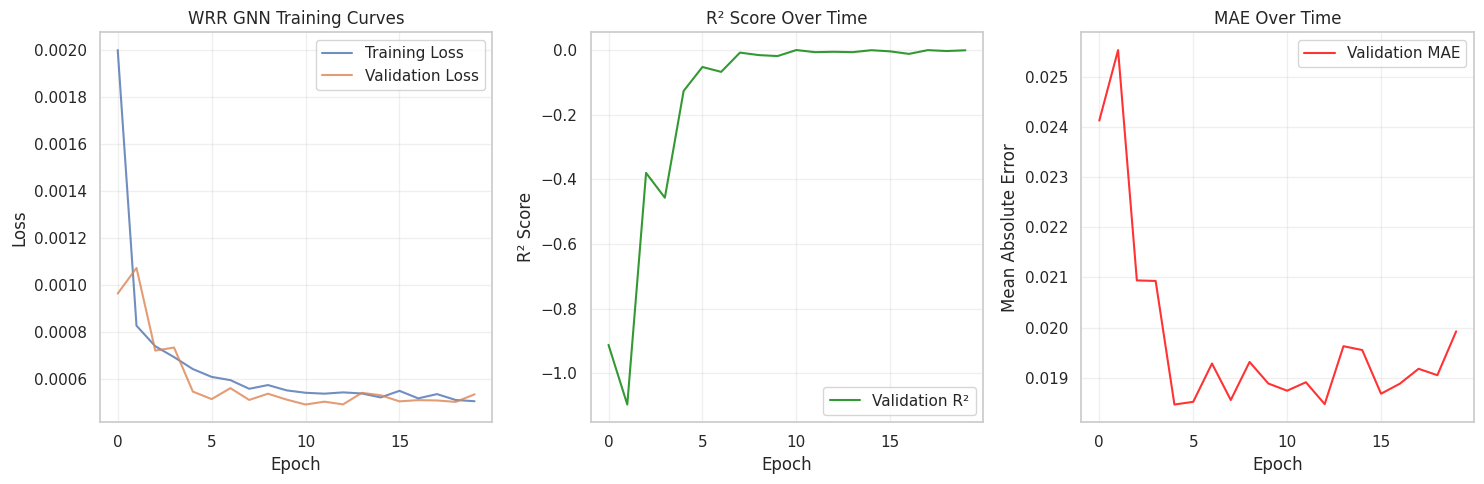

\n============================================================
FINAL TRAINING RESULTS
Training Time: 535.72 seconds
Total Epochs: 20
Final Training Loss: 0.0005
Final Validation Loss: 0.0005
Final Validation R²: -0.0004
Final Validation MAE: 0.0199
Best Validation R²: 0.0004
Best Validation MAE: 0.0185
Final Training Metrics:
  train_r2: -0.016268253326416016
  train_mae: 0.01917821541428566
  train_score_range: 0.627-0.644
Final Validation Metrics:
  val_r2: -0.00037539005279541016
  val_mae: 0.019928036257624626
  val_score_range: 0.635-0.636


In [30]:
# Plot training results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(training_results['train_losses'], label='Training Loss', alpha=0.8)
plt.plot(training_results['val_losses'], label='Validation Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('WRR GNN Training Curves')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(training_results['val_r2s'], label='Validation R²', alpha=0.8, color='green')
plt.xlabel('Epoch')
plt.ylabel('R² Score')
plt.legend()
plt.title('R² Score Over Time')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(training_results['val_maes'], label='Validation MAE', alpha=0.8, color='red')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('MAE Over Time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive training results
print("\\n" + "="*60)
print("FINAL TRAINING RESULTS")
print("="*60)
print(f"Training Time: {training_results['training_time']:.2f} seconds")
print(f"Total Epochs: {len(training_results['train_losses'])}")
print(f"Final Training Loss: {training_results['train_losses'][-1]:.4f}")
print(f"Final Validation Loss: {training_results['val_losses'][-1]:.4f}")
print(f"Final Validation R²: {training_results['val_r2s'][-1]:.4f}")
print(f"Final Validation MAE: {training_results['val_maes'][-1]:.4f}")
print(f"Best Validation R²: {max(training_results['val_r2s']):.4f}")
print(f"Best Validation MAE: {min(training_results['val_maes']):.4f}")

# Print detailed metrics if available
final_train_metrics = training_results['train_metrics'][-1] if training_results['train_metrics'] else {}
final_val_metrics = training_results['val_metrics'][-1] if training_results['val_metrics'] else {}

if final_train_metrics:
    print("Final Training Metrics:")
    for metric, value in final_train_metrics.items():
        print(f"  {metric}: {value}")

if final_val_metrics:
    print("Final Validation Metrics:")
    for metric, value in final_val_metrics.items():
        print(f"  {metric}: {value}")

## Model Evaluation and Prediction Analysis


[2025-07-16 11:41:37,819] INFO - Loaded best model from /root/projects/my-herosim/src/notebooks/models/best_wrr_gnn.pt
Evaluating model: 100%|██████████| 32/32 [00:04<00:00,  7.42it/s]


\n============================================================
COMPREHENSIVE WRR EVALUATION RESULTS
WRR Composite Score Prediction:
  MAE: 0.0198
  RMSE: 0.0250
  R²: -0.1690
  MAPE: 3.06%
  Score Range: 0.599 - 0.686
  Prediction Range: 0.625 - 0.626


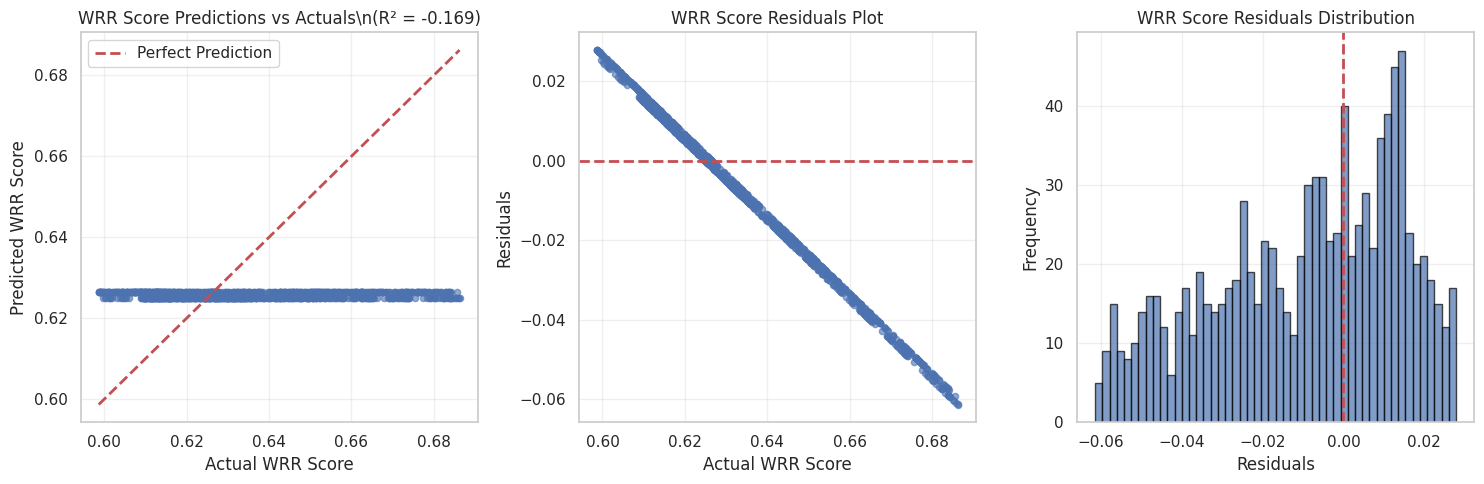

\n----------------------------------------
ERROR ANALYSIS BY WRR SCORE RANGE
----------------------------------------
0.4-0.6 : MAE=0.0272, R²=-5140.391, Count=  16
0.6-0.8 : MAE=0.0197, R²=-0.194, Count= 984


In [31]:
# Load best model for evaluation
best_checkpoint_path = os.path.join(MODEL_DIR, 'best_wrr_gnn.pt')
if os.path.exists(best_checkpoint_path):
    checkpoint = torch.load(best_checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    logger.info(f"Loaded best model from {best_checkpoint_path}")
else:
    # Use early stopping weights if checkpoint not available
    if hasattr(trainer, 'early_stopping') and trainer.early_stopping.best_weights:
        model.load_state_dict(trainer.early_stopping.best_weights)
        logger.info("Loaded best weights from early stopping")

# Detailed evaluation on validation set
model.eval()
all_predictions = []
all_actuals = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating model"):
        batch = batch.to(trainer.device)
        # Forward pass without batch parameter
        outputs = model(batch.x, batch.edge_index, batch.edge_attr)
        
        mask = batch.mask
        if mask.sum() > 0:
            # WRR score predictions
            score_pred = outputs['wrr_score'][mask].cpu().numpy()
            score_actual = batch.wrr_score_target[mask].cpu().numpy()
            
            all_predictions.extend(score_pred)
            all_actuals.extend(score_actual)

# Convert to numpy arrays
all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Calculate comprehensive metrics
mae = mean_absolute_error(all_actuals, all_predictions)
rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
r2 = r2_score(all_actuals, all_predictions)
mape = np.mean(np.abs((all_actuals - all_predictions) / all_actuals)) * 100

print("\\n" + "="*60)
print("COMPREHENSIVE WRR EVALUATION RESULTS")
print("="*60)
print(f"WRR Composite Score Prediction:")
print(f"  MAE: {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²: {r2:.4f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  Score Range: {all_actuals.min():.3f} - {all_actuals.max():.3f}")
print(f"  Prediction Range: {all_predictions.min():.3f} - {all_predictions.max():.3f}")

# Visualization of predictions vs actuals
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(all_actuals, all_predictions, alpha=0.6, s=20)
plt.plot([all_actuals.min(), all_actuals.max()], 
         [all_actuals.min(), all_actuals.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual WRR Score')
plt.ylabel('Predicted WRR Score')
plt.title(f'WRR Score Predictions vs Actuals\\n(R² = {r2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
residuals = all_predictions - all_actuals
plt.scatter(all_actuals, residuals, alpha=0.6, s=20)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Actual WRR Score')
plt.ylabel('Residuals')
plt.title('WRR Score Residuals Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('WRR Score Residuals Distribution')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error analysis by WRR score range
print("\\n" + "-"*40)
print("ERROR ANALYSIS BY WRR SCORE RANGE")
print("-"*40)

# Define WRR score ranges (typically 0-1 for normalized scores)
ranges = [(0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
for low, high in ranges:
    mask = (all_actuals >= low) & (all_actuals < high)
    if mask.sum() > 0:
        range_mae = mean_absolute_error(all_actuals[mask], all_predictions[mask])
        range_r2 = r2_score(all_actuals[mask], all_predictions[mask])
        count = mask.sum()
        range_name = f"{low:.1f}-{high:.1f}"
        print(f"{range_name:8s}: MAE={range_mae:6.4f}, R²={range_r2:6.3f}, Count={count:4d}")

## Save Model

In [34]:
# Final WRR model checkpoint
final_checkpoint_path = os.path.join(MODEL_DIR, 'wrr_gnn_final.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'training_results': training_results,
    'best_val_loss': trainer.early_stopping.best_loss if hasattr(trainer, 'early_stopping') else None,
    'feature_dim': model.node_feature_dim,
    'edge_dim': model.edge_feature_dim
}, final_checkpoint_path)

print(f"✅ Final model saved to {final_checkpoint_path}")

✅ Final model saved to /root/projects/my-herosim/src/notebooks/models/wrr_gnn_final.pt
